<a href="https://colab.research.google.com/github/tatianajoli/Sleep-Quality-and-Depression-Risk-Among-Bachelors-Degree-Candidates/blob/main/CS439_Final_Project_Debby_%26_Tatiana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 😄 **Welcome to Our <font color='crimson'>** **Data Science Project! 😄**</font>

**The Impact of Sleep Quality on Depression Risk Among College Students Pursuing a Bachelor's Degree**

**Data Citing:**

Healthy Minds Network 2023-2024. Healthy Minds Study among Colleges and Universities, year (HMS years of data being used) [Data set]. Healthy Minds Network, University of Michigan, University of California Los Angeles, Boston University, and Wayne State University. https://healthymindsnetwork.org/research/data-for-researchers.

**Link to Final 2023-2024 Codebook:**

https://healthymindsnetwork.org/wp-content/uploads/2024/10/2023-24-Codebook_Student_FS_100724.pdf

---

## <font color='crimson'>**Project Information and Background:**</font>

**Research Question:**

Does poor sleep quality (Poor, Fair, Good) correlate with a higher risk of depression among students pursuing a bachelor's degree?

**Context and Motivation:**

Analyzing students' self-reported sleep quality through surveys allows us to correlate it with depression rates. Many students, especially those pursuing a bachelor's degree, accept poor sleep and irregular sleep patterns as a norm due to academic pressures, social and emotional stressors, lifestyle changes, and the transition to independence. Our goal is to challenge this norm, shifting the focus from late-night study sessions and high stress to the importance of sleep quality. We aim to show that inadequate sleep can significantly harm mental health, increasing vulnerability to depression. While the relationship between sleep quality and depression is not fully understood, particularly in the context of academic pressures, this research will provide valuable insights and help develop solutions to improve student well-being. Additionally, fostering a healthier learning environment can enhance student success rates, making the institution more attractive to prospective students.

**Broader Implications of Work:**

Our research aims to provide recommendations to 4-year undergraduate universities in the U.S. to revise or implement policies and workshops that prioritize better sleep habits for students. If a clear link between sleep quality and mental health is found through our research, this could give incentive for targeted interventions in colleges; including sleep hygiene education, enhanced counseling services, and academic adjustments. These changes could significantly improve students' well-being, reduce stress, and enhance academic performance.

## <font color='crimson'>**Data Preparation**</font>
GOAL: The main goal of this milestone is to set up our environment, install the required packages, and access data and do some basic exploratory data analysis.

In [ ]:
# Step 1: Setting up libraries and installing packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Step 2: Accessing our needed data
# Since this is a large dataset, we uploaded our data by mounting our Google Drives
from google.colab import drive
drive.mount('/content/drive')

# Step 3: Read the data (make sure you already downloaded it and uploaded it to your google drive)
data = pd.read_csv("/content/drive/MyDrive/HMS_2023-2024_PUBLIC_instchars.csv")
print(data.columns.tolist())

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Step 4: Let's see what the data looks like
data.head()

,StartDate,RecordedDate,responseid,age,sex_birth,gender_male,gender_female,gender_queer,gender_nonbin,gender_trans,...,inst_public,inst_geo,inst_specart,inst_speccc,inst_gradrate,inst_msi,peercohort,Random,sleep_wknight,sleep_wkend
0,16nov2023 22:51:41,05dec2023 08:17:37,R_006AKYXyGhT9Upb,18.0,1.0,NaN,1.0,NaN,NaN,NaN,...,1,8,0,0,0.25,0,3.0,0.719747,NaN,NaN
1,16nov2023 17:12:11,16nov2023 17:37:33,R_006rfKhxwocpzmF,18.0,1.0,NaN,1.0,NaN,NaN,NaN,...,1,8,0,0,0.25,0,3.0,0.219248,7.0,6.0
2,24sep2023 18:29:45,24sep2023 18:53:25,R_009nvDs0qZwqoW5,18.0,2.0,1.0,NaN,NaN,NaN,NaN,...,1,5,0,0,0.50,0,3.0,0.756233,NaN,NaN
3,30oct2023 08:01:53,21nov2023 07:17:23,R_00R9rAHb09Ydma5,20.0,1.0,NaN,1.0,NaN,NaN,NaN,...,1,3,0,0,0.24,0,3.0,0.133426,6.0,8.0
4,24oct2023 09:49:54,21nov2023 07:57:58,R_00SNQFMZ5Kok7Hr,21.0,2.0,1.0,NaN,NaN,NaN,NaN,...,0,5,0,0,0.57,0,1.0,0.773790,NaN,NaN


In [ ]:
#Step 5: Describe the data
desc_stats = data.describe()
desc_stats

,age,sex_birth,gender_male,gender_female,gender_queer,gender_nonbin,gender_trans,gender_prefnoresp,gender_selfID,sexual_h,...,inst_public,inst_geo,inst_specart,inst_speccc,inst_gradrate,inst_msi,peercohort,Random,sleep_wknight,sleep_wkend
count,104729.000000,104590.000000,29291.0,71099.0,3026.0,3517.0,2003.0,609.0,643.0,74229.0,...,104729.000000,104729.000000,104729.000000,104729.000000,104729.000000,104729.000000,104622.000000,104108.000000,47230.000000,47218.000000
mean,23.734247,1.282704,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.760849,5.047971,0.007830,0.182137,0.379970,0.222269,3.218510,0.501566,6.496782,7.108412
std,7.668968,0.451694,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.426567,2.422342,0.088139,0.385959,0.194209,0.415773,1.242504,0.289335,1.414775,1.161267
min,18.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.000000,1.000000,0.000000,0.000000,0.020000,0.000000,1.000000,0.000006,1.000000,1.000000
25%,19.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.000000,3.000000,0.000000,0.000000,0.230000,0.000000,3.000000,0.249938,6.000000,7.000000
50%,21.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.000000,5.000000,0.000000,0.000000,0.320000,0.000000,3.000000,0.500960,6.000000,8.000000
75%,25.000000,2.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.000000,7.000000,0.000000,0.000000,0.500000,0.000000,4.000000,0.753617,7.000000,8.000000
max,120.000000,3.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.000000,9.000000,1.000000,1.000000,0.990000,1.000000,6.000000,0.999993,9.000000,8.000000


##<font color='crimson'> **Data Ethics and Pre-Processing** </font>
GOAL: The main goal is to assess the dataset, find missing values, and decide what to do with those missing data points.

In [ ]:
# Step 1: Select only the cols necessary for data analysis
cols_add = [
    "enroll", "degree_bach", "gr_A", "gr_B", "gr_C", "gr_D", "gr_F",
    "anymhprob", "sleep_wknight", "sleep_wkend"]
cols = [col for col in data.columns if col in cols_add]

data = data[cols]
data.head(15)

,degree_bach,enroll,gr_A,gr_B,gr_C,gr_D,gr_F,anymhprob,sleep_wknight,sleep_wkend
0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,NaN,NaN
1,1.0,1.0,1.0,NaN,NaN,NaN,NaN,1.0,7.0,6.0
2,1.0,1.0,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN
3,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,6.0,8.0
4,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
5,NaN,1.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN
6,NaN,1.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN
7,1.0,1.0,NaN,NaN,1.0,NaN,NaN,1.0,6.0,7.0
8,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,5.0,5.0
9,1.0,1.0,NaN,1.0,1.0,NaN,NaN,1.0,NaN,NaN


In [ ]:
# Step 2: Checking data for missing values
missing_values = data.isnull().sum()

# Turn the missing value counts into percentages
missing_values_percentage = (missing_values / len(data)) * 100

# Return counts and percentages of missing values in each column
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_values_percentage})
missing_data.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
gr_F,104412,99.697314
gr_D,103696,99.013645
gr_C,92577,88.396719
sleep_wkend,57511,54.914112
sleep_wknight,57499,54.902654
gr_B,52098,49.745534
degree_bach,42182,40.277287
gr_A,33077,31.583420
anymhprob,13052,12.462642
enroll,3528,3.368694


In [ ]:
# Step 3: Addressing missing values

# All entries must have responses for: degree_bach, enroll, anymhprob, sleep_wknight, and sleep_wkend
# Drop rows where any of these cols have NaN values
data = data.dropna(subset=["degree_bach", "enroll", "anymhprob", "sleep_wknight", "sleep_wkend"])

# Students must be enrolled full-time in a bachelor's degree
# Correctly set to 1 for bachelor enrollment
# Correctly set to 1 for full time enrollment
data = data[(data["degree_bach"] == 1) & (data["enroll"] == 1)]

# Fill remaining NaN values with 0 since remaining cols are binary (0 would equal No)
data = data.fillna(0)

# Student must have at least one valid letter grade for their GPA (A, B, C, D, F)
# Remove entries that don't follow this restraint (every val in each col is 0)
data = data[data["gr_A"] + data["gr_B"] + data["gr_C"] + data["gr_D"] + data["gr_F"] > 1].reset_index(drop=True)

data.head(10)

,degree_bach,enroll,gr_A,gr_B,gr_C,gr_D,gr_F,anymhprob,sleep_wknight,sleep_wkend
0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,6.0,8.0
1,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,5.0,5.0
2,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,9.0,7.0
3,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,9.0,8.0
4,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,9.0,8.0
5,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,7.0,6.0
6,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,9.0,8.0
7,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,6.0,8.0
8,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,4.0,5.0
9,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,5.0,8.0


## <font color= "crimson"> **Basic Exploration** </font>

GOAL: The main goal is to directly compare.

Notes:

Our control group is NO mental health problems: anymhprob=0.

- Test run: gr_A (Q2.21.0) gr_B (Q2.21.1) gr_C (Q2.21.2)

- Test run: gr_D (Q2.21.3) gr_F (Q2.21.4)

Our trained model is YES mental health problems: anymhprob=1.

- Test run: gr_A (Q2.21.0) gr_B (Q2.21.1) gr_C (Q2.21.2)

- Test run: gr_D (Q2.21.3) gr_F (Q2.21.4)

**Analysis:**

Students with mental health problems tend to:

1. Have slightly lower A grades.

2. Sleep less on weeknights.

3. Still perform well, but less consistently than those without mental health concerns.

Students with bad grades and mental health problems:

1. Sleep significantly less, especially on weeknights.

This suggests a possible link between poor sleep, mental health, and academic performance.

**Final Insights:**
1. Mental health problems correlate with slightly lower performance and less sleep.

2. Students with bad grades and poor sleep tend to have more mental health concerns.

3. Weeknight sleep appears to be more affected than weekend sleep across the board.

**Question 1: What are your grades when you do and don't have mental health problems?**

**Question 2: What are your grades when you do and don't enough sleep?**

In [ ]:
good_grades = (
    # only As
    ((data["gr_A"] == 1) & (data[["gr_B", "gr_C", "gr_D", "gr_F"]].sum(axis=1) == 0)) |
    # As and/or Bs but no Ds or Fs
    ((data[["gr_A", "gr_B"]].sum(axis=1) > 0) & (data[["gr_D", "gr_F"]].sum(axis=1) == 0))
)

bad_grades = (
    # at least 2 Cs, Ds, and Fs but no As
    ((data[["gr_C", "gr_D", "gr_F"]].sum(axis=1) >= 2) & (data["gr_A"] == 0)) |
    # as many or more Cs, Ds, and Fs than As and Bs
    (data[["gr_C", "gr_D", "gr_F"]].sum(axis=1) >= data[["gr_A", "gr_B"]].sum(axis=1))
)

In [ ]:
#good grade and sleep analysis (no mh problems)
data[(good_grades) & (data["anymhprob"] == 0)].describe()

,degree_bach,enroll,gr_A,gr_B,gr_C,gr_D,gr_F,anymhprob,sleep_wknight,sleep_wkend
count,4355.0,4355.0,4355.000000,4355.000000,4355.000000,4355.0,4355.0,4355.0,4355.000000,4355.000000
mean,1.0,1.0,0.842021,0.984845,0.173134,0.0,0.0,0.0,6.799082,7.302181
std,0.0,0.0,0.364764,0.122183,0.378407,0.0,0.0,0.0,1.275831,0.969959
min,1.0,1.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.000000,1.000000
25%,1.0,1.0,1.000000,1.000000,0.000000,0.0,0.0,0.0,6.000000,7.000000
50%,1.0,1.0,1.000000,1.000000,0.000000,0.0,0.0,0.0,7.000000,8.000000
75%,1.0,1.0,1.000000,1.000000,0.000000,0.0,0.0,0.0,7.000000,8.000000
max,1.0,1.0,1.000000,1.000000,1.000000,0.0,0.0,0.0,9.000000,8.000000


In [ ]:
#good grade and sleep analysis (yes mh problems)
data[(good_grades) & (data["anymhprob"] == 1)].describe()

,degree_bach,enroll,gr_A,gr_B,gr_C,gr_D,gr_F,anymhprob,sleep_wknight,sleep_wkend
count,8120.0,8120.0,8120.000000,8120.000000,8120.000000,8120.0,8120.0,8120.0,8120.000000,8120.000000
mean,1.0,1.0,0.770813,0.976847,0.252340,0.0,0.0,1.0,6.218103,7.025246
std,0.0,0.0,0.420336,0.150398,0.434382,0.0,0.0,0.0,1.433106,1.257167
min,1.0,1.0,0.000000,0.000000,0.000000,0.0,0.0,1.0,1.000000,1.000000
25%,1.0,1.0,1.000000,1.000000,0.000000,0.0,0.0,1.0,5.000000,6.000000
50%,1.0,1.0,1.000000,1.000000,0.000000,0.0,0.0,1.0,6.000000,8.000000
75%,1.0,1.0,1.000000,1.000000,1.000000,0.0,0.0,1.0,7.000000,8.000000
max,1.0,1.0,1.000000,1.000000,1.000000,0.0,0.0,1.0,9.000000,8.000000


In [ ]:
#bad grade and sleep analysis (no mh problems)
data[(bad_grades) & (data["anymhprob"] == 0)].describe()

,degree_bach,enroll,gr_A,gr_B,gr_C,gr_D,gr_F,anymhprob,sleep_wknight,sleep_wkend
count,816.0,816.0,816.000000,816.000000,816.000000,816.000000,816.000000,816.0,816.000000,816.000000
mean,1.0,1.0,0.088235,0.855392,0.976716,0.069853,0.009804,0.0,6.523284,7.128676
std,0.0,0.0,0.283811,0.351921,0.150898,0.255055,0.098589,0.0,1.334561,1.172009
min,1.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,1.000000
25%,1.0,1.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,6.000000,7.000000
50%,1.0,1.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,6.000000,8.000000
75%,1.0,1.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,7.000000,8.000000
max,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,9.000000,8.000000


In [ ]:
#bad grade and sleep analysis (yes mh problems)
data[(bad_grades) & (data["anymhprob"] == 1)].describe()

,degree_bach,enroll,gr_A,gr_B,gr_C,gr_D,gr_F,anymhprob,sleep_wknight,sleep_wkend
count,2277.0,2277.0,2277.000000,2277.000000,2277.000000,2277.000000,2277.000000,2277.0,2277.000000,2277.000000
mean,1.0,1.0,0.094422,0.831357,0.967940,0.087396,0.018884,1.0,5.976285,6.855951
std,0.0,0.0,0.292480,0.374518,0.176197,0.282476,0.136147,0.0,1.470973,1.390520
min,1.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.000000,1.000000
25%,1.0,1.0,0.000000,1.000000,1.000000,0.000000,0.000000,1.0,5.000000,6.000000
50%,1.0,1.0,0.000000,1.000000,1.000000,0.000000,0.000000,1.0,6.000000,7.000000
75%,1.0,1.0,0.000000,1.000000,1.000000,0.000000,0.000000,1.0,7.000000,8.000000
max,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,9.000000,8.000000


In [ ]:
#SUMMARY CHART
summary_data = {
    "Group": [
        "Good grades, no MH problems",
        "Good grades, with MH problems",
        "Bad grades, no MH problems",
        "Bad grades, with MH problems"
    ],
    "A Grades": [0.842, 0.771, 0.088, 0.094],
    "Weeknight Sleep": [6.0, 6.22, 6.52, 5.98],
    "Weekend Sleep": [7.3, 7.03, 7.13, 6.89]
}

# Convert to DataFrame
summary_df = pd.DataFrame(summary_data)

# Display the DataFrame
print(summary_df)

                           Group  A Grades  Weeknight Sleep  Weekend Sleep
0    Good grades, no MH problems     0.842             6.00           7.30
1  Good grades, with MH problems     0.771             6.22           7.03
2     Bad grades, no MH problems     0.088             6.52           7.13
3   Bad grades, with MH problems     0.094             5.98           6.89


##<font color='crimson'> **Graphing**</font>

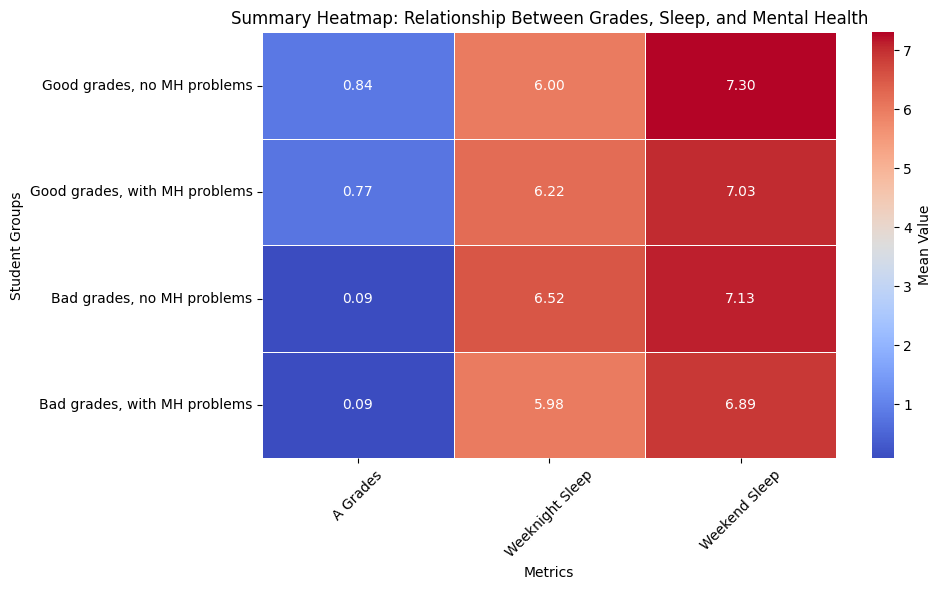

In [ ]:
#HEATMAP
# Set 'Group' as index for the heatmap
heatmap_data = summary_df.set_index("Group")

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, cbar_kws={"label": "Mean Value"})

# Heatmap formatting
plt.title("Summary Heatmap: Relationship Between Grades, Sleep, and Mental Health")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.xlabel("Metrics")
plt.ylabel("Student Groups")
plt.tight_layout()
plt.show()

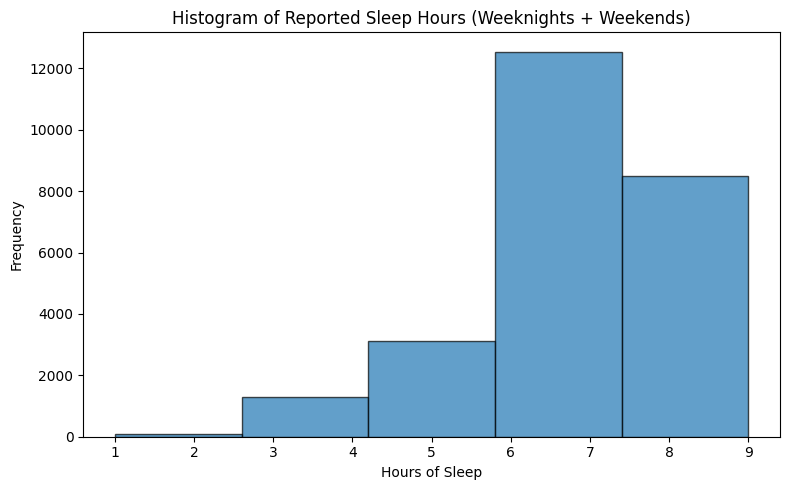

In [ ]:
#HISTOGRAM
# Flatten all sleep values into one list to simulate a histogram
all_sleep_hours = data["sleep_wknight"].tolist() + data["sleep_wkend"].tolist()

plt.figure(figsize=(8, 5))
plt.hist(all_sleep_hours, bins=5, edgecolor="black", alpha=0.7)
plt.title("Histogram of Reported Sleep Hours (Weeknights + Weekends)")
plt.xlabel("Hours of Sleep")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

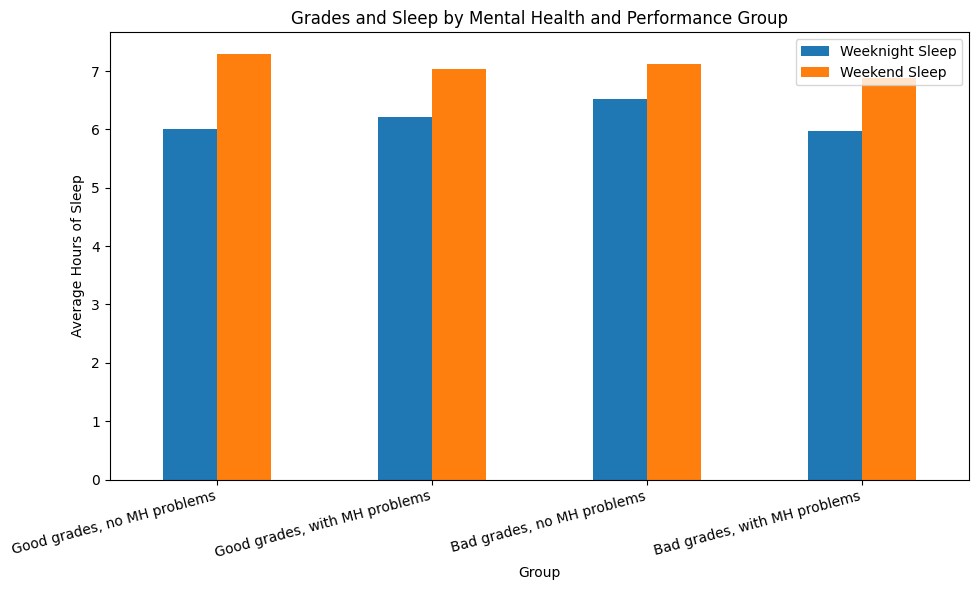

In [ ]:
summary_df = summary_df.drop("A Grades", axis=1)

plt.figure(figsize=(8, 5))
summary_df.set_index("Group").plot(kind="bar", figsize=(10, 6))
plt.title("Grades and Sleep by Mental Health and Performance Group")
plt.ylabel("Average Hours of Sleep")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.legend(loc="upper right")
plt.show()

In [ ]:
#CHI-SQUARE TEST
table = pd.crosstab(data['anymhprob'], bad_grades)
chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-Squared = {chi2} \np = {p}")

Chi-Squared = 121.41690854351748 
p = 3.097046421599765e-28


In [ ]:
#K-MEANS CLUSTERING
features = data[[
    "gr_A", "gr_B", "gr_C", "gr_D", "gr_F",
    "anymhprob", "sleep_wknight", "sleep_wkend"
]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

data['cluster'] = clusters
cluster_summary = data.groupby('cluster')[
    ["gr_A", "gr_B", "gr_C", "gr_D", "gr_F", "anymhprob", "sleep_wknight", "sleep_wkend"]
].mean()

print(cluster_summary)

             gr_A      gr_B      gr_C      gr_D  gr_F  anymhprob  \
cluster                                                            
0        1.000000  1.000000  0.000000  0.000000   0.0   0.999835   
1        0.089474  0.849013  0.983553  0.077961   0.0   0.734868   
2        1.000000  0.999445  0.000000  0.000555   0.0   0.000000   
3        0.254902  0.196078  0.215686  0.333333   1.0   0.843137   

         sleep_wknight  sleep_wkend  
cluster                              
0             6.294137     7.076087  
1             6.127303     6.935855  
2             6.861188     7.337590  
3             5.607843     6.411765  
